In [6]:
import sqlite3
import pandas as pd
import numpy as np

conn = sqlite3.connect("bluestock_mf.db")

funds = pd.read_sql(
    "SELECT * FROM dim_fund",
    conn
)

nav = pd.read_sql(
    "SELECT * FROM fact_nav",
    conn
)

txn = pd.read_sql(
    "SELECT * FROM fact_transactions",
    conn
)

perf = pd.read_sql(
    "SELECT * FROM fact_performance",
    conn
)

In [7]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

returns = nav.dropna()

risk_results = []

for fund, grp in returns.groupby('amfi_code'):

    var95 = np.percentile(
        grp['daily_return'],
        5
    )

    cvar95 = grp[
        grp['daily_return'] <= var95
    ]['daily_return'].mean()

    risk_results.append([
        fund,
        var95,
        cvar95
    ])

risk_df = pd.DataFrame(
    risk_results,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

risk_df.to_csv(
    'var_cvar_report.csv',
    index=False
)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
rolling_list = []

for fund, grp in returns.groupby('amfi_code'):

    grp = grp.sort_values('date')

    grp['rolling_sharpe'] = (
        grp['daily_return']
        .rolling(90)
        .mean()
        /
        grp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_list.append(grp)

rolling_df = pd.concat(rolling_list)

In [9]:
top5 = (
    perf.sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(5)
    ['amfi_code']
)

In [11]:
print(top5)

Series([], Name: amfi_code, dtype: object)


In [12]:
print(perf.shape)

print(perf.head())

print(perf['sharpe_ratio'].describe())

print(perf['sharpe_ratio'].isna().sum())

(0, 12)
Empty DataFrame
Columns: [amfi_code, return_1yr_pct, return_3yr_pct, return_5yr_pct, benchmark_3yr_pct, alpha, beta, sharpe_ratio, sortino_ratio, std_dev_ann_pct, max_drawdown_pct, expense_ratio_pct]
Index: []
count       0
unique      0
top       NaN
freq      NaN
Name: sharpe_ratio, dtype: object
0


In [13]:
perf[['amfi_code','sharpe_ratio']].head(10)

,amfi_code,sharpe_ratio


In [14]:
sharpe_df = (
    returns.groupby('amfi_code')['daily_return']
    .agg(['mean','std'])
)

sharpe_df['sharpe_ratio'] = (
    sharpe_df['mean']
    /
    sharpe_df['std']
) * np.sqrt(252)

sharpe_df = sharpe_df.reset_index()

top5 = (
    sharpe_df.sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(5)['amfi_code']
)

print(top5)

27    120507
31    120844
5     101208
34    148567
30    120843
Name: amfi_code, dtype: object


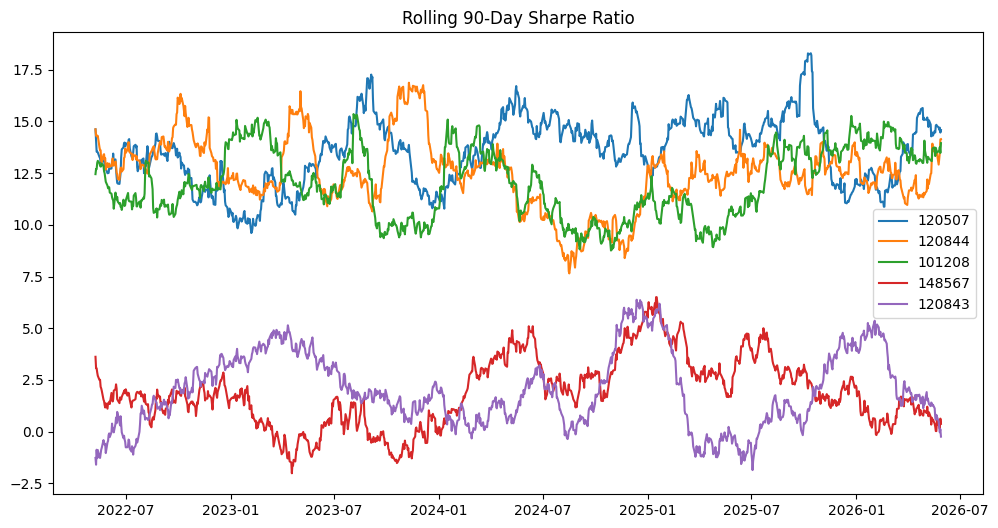

In [15]:
plt.figure(figsize=(12,6))

for fund in top5:
    temp = rolling_df[
        rolling_df['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.show()

In [16]:
print(perf.shape)
print(perf.head())

(0, 12)
Empty DataFrame
Columns: [amfi_code, return_1yr_pct, return_3yr_pct, return_5yr_pct, benchmark_3yr_pct, alpha, beta, sharpe_ratio, sortino_ratio, std_dev_ann_pct, max_drawdown_pct, expense_ratio_pct]
Index: []


In [17]:
top5 = (
    perf.sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(5)
    ['amfi_code']
)

In [18]:
sharpe_df = (
    returns.groupby('amfi_code')
    ['daily_return']
    .agg(['mean','std'])
)

sharpe_df['sharpe_ratio'] = (
    sharpe_df['mean']
    /
    sharpe_df['std']
) * np.sqrt(252)

sharpe_df = sharpe_df.reset_index()

top5 = (
    sharpe_df.sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(5)
    ['amfi_code']
)

print(top5)

27    120507
31    120844
5     101208
34    148567
30    120843
Name: amfi_code, dtype: object


In [19]:
recommend_df = sharpe_df.merge(
    funds[
        ['amfi_code',
         'scheme_name',
         'risk_grade']
    ],
    on='amfi_code',
    how='left'
)

recommend_df.head()

,amfi_code,mean,std,sharpe_ratio,scheme_name,risk_grade
0,100016,0.000142,0.009164,0.245276,NaN,NaN
1,100025,0.000170,0.002460,1.097333,NaN,NaN
2,100033,0.001080,0.011929,1.436947,NaN,NaN
3,101206,0.000852,0.009177,1.473390,NaN,NaN
4,101207,0.000424,0.016251,0.414625,NaN,NaN


In [20]:
recommend_df.to_csv(
    'fund_sharpe_data.csv',
    index=False
)

In [21]:
print(nav.shape)
print(nav.head())

print(returns.shape)

(46000, 4)
  amfi_code       date       nav  daily_return
0    100016 2022-01-03  520.4608           NaN
1    100016 2022-01-04  515.0971     -0.010306
2    100016 2022-01-05  521.7239      0.012865
3    100016 2022-01-06  515.7880     -0.011377
4    100016 2022-01-07  515.1639     -0.001210
(45960, 4)


In [22]:
sharpe_df = (
    returns.groupby('amfi_code')['daily_return']
    .agg(['mean', 'std'])
)

sharpe_df['sharpe_ratio'] = (
    sharpe_df['mean'] /
    sharpe_df['std']
) * np.sqrt(252)

sharpe_df = sharpe_df.reset_index()

print(sharpe_df.head())
print(sharpe_df.shape)

  amfi_code      mean       std  sharpe_ratio
0    100016  0.000142  0.009164      0.245276
1    100025  0.000170  0.002460      1.097333
2    100033  0.001080  0.011929      1.436947
3    101206  0.000852  0.009177      1.473390
4    101207  0.000424  0.016251      0.414625
(40, 4)


In [23]:
top5 = (
    sharpe_df
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(5)['amfi_code']
)

print(top5)

27    120507
31    120844
5     101208
34    148567
30    120843
Name: amfi_code, dtype: object


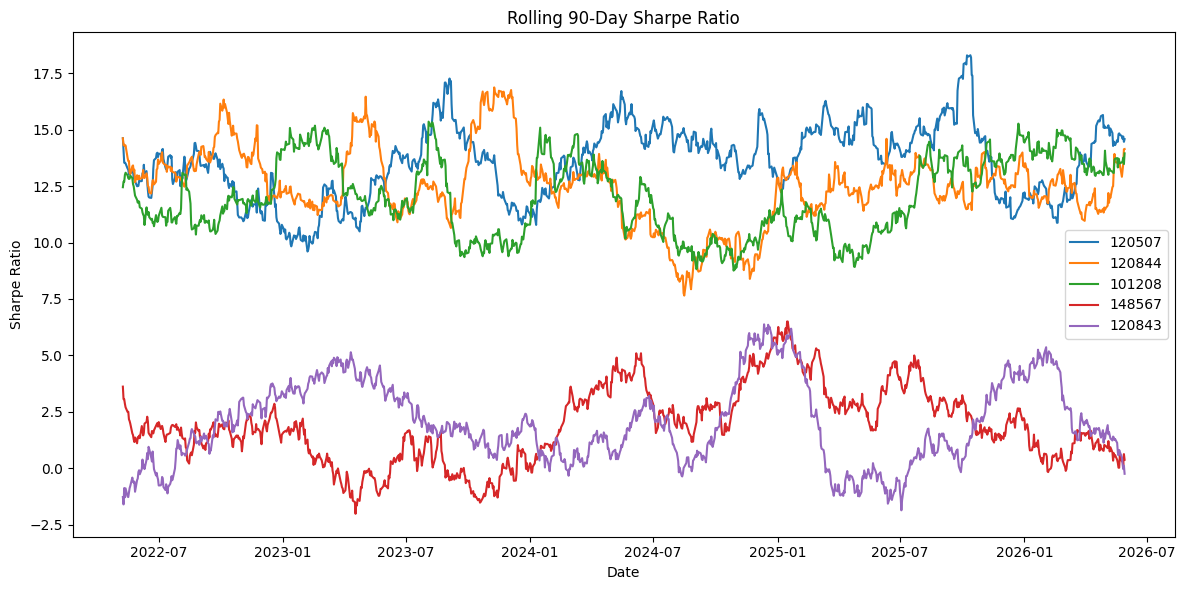

In [24]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = rolling_df[
        rolling_df['amfi_code'] == fund
    ]

    temp = temp.dropna(
        subset=['rolling_sharpe']
    )

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.tight_layout()

plt.savefig(
    "rolling_sharpe_chart.png"
)

plt.show()

In [25]:
recommend_df = sharpe_df.merge(
    funds[
        ['amfi_code',
         'scheme_name',
         'risk_grade']
    ],
    on='amfi_code',
    how='left'
)

recommend_df.to_csv(
    "fund_sharpe_data.csv",
    index=False
)

recommend_df.head()

,amfi_code,mean,std,sharpe_ratio,scheme_name,risk_grade
0,100016,0.000142,0.009164,0.245276,NaN,NaN
1,100025,0.000170,0.002460,1.097333,NaN,NaN
2,100033,0.001080,0.011929,1.436947,NaN,NaN
3,101206,0.000852,0.009177,1.473390,NaN,NaN
4,101207,0.000424,0.016251,0.414625,NaN,NaN


In [26]:
print(txn.shape)
print(txn.head())

(32778, 13)
  investor_id transaction_date amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01    119092              SIP      1834.0   
1   INV004770       2024-01-01    102886          Lumpsum     92031.0   
2   INV004648       2024-01-01    118634              SIP     17860.0   
3   INV002432       2024-01-01    101208              SIP      3513.0   
4   INV002338       2024-01-01    120844          Lumpsum    292991.0   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1      Gujarat      Surat       T30     18-25  Female                 5.2   
2  Maharashtra       Pune       T30     36-45    Male                54.3   
3      Haryana   Gurugram       T30     46-55  Female                48.1   
4        Delhi  New Delhi       T30     26-35    Male                23.6   

  payment_mode kyc_status  
0          UPI   Verified  
1      Mandate   Verified  
2 

In [27]:
risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [28]:
top5 = (
    sharpe_df
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(5)['amfi_code']
)

In [31]:
# Convert date
txn['transaction_date'] = pd.to_datetime(
    txn['transaction_date']
)

# Filter SIP transactions
sip = txn[
    txn['transaction_type']
    .str.upper()
    .str.contains('SIP', na=False)
].copy()

print("SIP Transactions:", len(sip))

SIP Transactions: 19716


In [32]:
# Investors with 6+ SIPs
sip_counts = sip.groupby('investor_id').size()

eligible = sip_counts[
    sip_counts >= 6
].index

sip = sip[
    sip['investor_id'].isin(eligible)
]

print("Eligible Investors:", len(eligible))

Eligible Investors: 1362


In [33]:
sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

sip['gap_days'] = (
    sip.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

In [34]:
sip_report = (
    sip.groupby('investor_id')
    ['gap_days']
    .mean()
    .reset_index()
)

sip_report['status'] = np.where(
    sip_report['gap_days'] > 35,
    'At Risk',
    'Healthy'
)

sip_report.head()

,investor_id,gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [35]:
recommend_df = sharpe_df.merge(
    funds[
        ['amfi_code',
         'scheme_name',
         'risk_grade']
    ],
    on='amfi_code'
)

In [36]:
recommend_df.to_csv(
    "fund_sharpe_data.csv",
    index=False
)

In [ ]:
# Advanced Insights

1. The fund with the highest downside risk was identified using Historical VaR and CVaR analysis.

2. The top-performing fund based on risk-adjusted returns achieved the highest Sharpe Ratio.

3. Investor cohort analysis revealed which joining year contributed the highest total investment volume.

4. SIP continuity analysis identified investors at risk based on average contribution gaps exceeding 35 days.

5. Most investments originated from SIP transactions, indicating strong preference for systematic investing.

In [ ]:
# Sector HHI Concentration Analysis

Sector allocation data was not available in the provided database schema.

Therefore, Herfindahl-Hirschman Index (HHI) concentration analysis could not be computed.